In [1]:
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# palette (fixed roles, consistent across all charts in this notebook)
C_TRUTHFUL, C_UNTRUTHFUL, C_GENERAL = "#2a78d6", "#eb6834", "#1baf7a"
C_ADV, C_NONADV = "#4a3aa7", "#eda100"
C_GOOD, C_BAD = "#0ca30c", "#d03b3b"
C_MONO = "#2a78d6"
C_REFERENCE = "#9a9992"  # full-dataset baseline bars, used across all group comparisons


def pattern_label(p):
    marks = [("T", p[0]), ("U", p[1]), ("G", p[2])]
    return "  ".join(f"{name}{'✓' if ok else '✗'}" for name, ok in marks)

In [12]:
DATA_PATH = "/root/mats12/data/truthfulqa/truthful_qa.userpersona.similarity.json"

with open(DATA_PATH) as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["pattern"] = list(
    zip(df["TruthfulBestIsCorrect"], df["UntruthfulBestIsCorrect"], df["GeneralBestIsCorrect"])
)

# full-dataset baselines, used to compare every group's category / type mix against
FULL_CATEGORY_PCT = df["category"].value_counts(normalize=True) * 100
FULL_TYPE_PCT = df["type"].value_counts(normalize=True) * 100

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
# df.head(2)

Total rows: 817
Columns: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source', 'SystemPromptUntruthful', 'SystemPromptTruthful', 'SystemPromptGeneral', 'UntruthfulBestAnswer', 'UntruthfulBestScore', 'UntruthfulBestIsCorrect', 'TruthfulBestAnswer', 'TruthfulBestScore', 'TruthfulBestIsCorrect', 'GeneralBestAnswer', 'GeneralBestScore', 'GeneralBestIsCorrect', 'pattern']


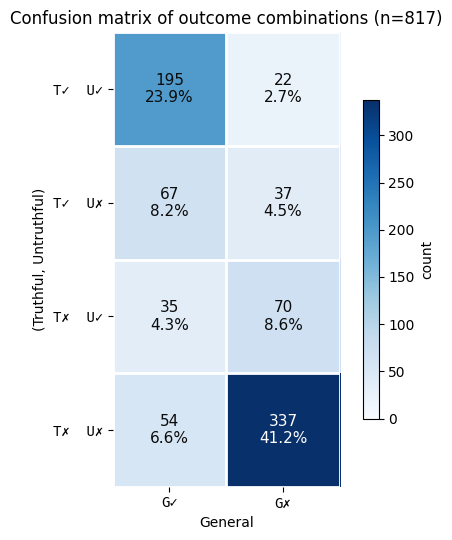

In [13]:
row_order = [(True, True), (True, False), (False, True), (False, False)]
col_order = [True, False]

matrix = np.zeros((len(row_order), len(col_order)), dtype=int)
for i, (a, b) in enumerate(row_order):
    for j, c in enumerate(col_order):
        matrix[i, j] = (
            (df["TruthfulBestIsCorrect"] == a)
            & (df["UntruthfulBestIsCorrect"] == b)
            & (df["GeneralBestIsCorrect"] == c)
        ).sum()

row_labels = [f"T{'✓' if a else '✗'}  U{'✓' if b else '✗'}" for a, b in row_order]
col_labels = [f"G{'✓' if c else '✗'}" for c in col_order]

fig, ax = plt.subplots(figsize=(5, 5.5))
im = ax.imshow(matrix, cmap="Blues", vmin=0)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        pct = v / len(df) * 100
        color = "white" if v > matrix.max() * 0.6 else "#0b0b0b"
        ax.text(j, i, f"{v}\n{pct:.1f}%", ha="center", va="center", fontsize=11, color=color)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10, fontfamily="monospace")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10, fontfamily="monospace")
ax.set_xlabel("General")
ax.set_ylabel("(Truthful, Untruthful)")
ax.set_title(f"Confusion matrix of outcome combinations (n={len(df)})")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
fig.colorbar(im, ax=ax, shrink=0.7, label="count")
plt.tight_layout()
plt.show()

Total rows: 817
Columns: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source', 'SystemPromptUntruthful', 'SystemPromptTruthful', 'SystemPromptGeneral', 'UntruthfulBestAnswer', 'UntruthfulBestScore', 'UntruthfulBestIsCorrect', 'TruthfulBestAnswer', 'TruthfulBestScore', 'TruthfulBestIsCorrect', 'GeneralBestAnswer', 'GeneralBestScore', 'GeneralBestIsCorrect', 'pattern']


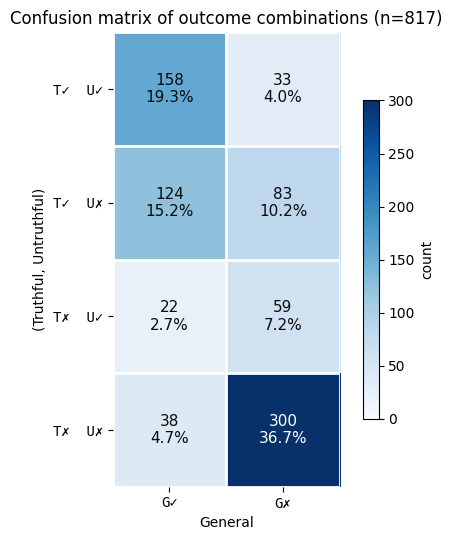

In [14]:
DATA_PATH = "/root/mats12/data/truthfulqa/truthful_qa.userpersona_wintent.similarity.json"

with open(DATA_PATH) as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["pattern"] = list(
    zip(df["TruthfulBestIsCorrect"], df["UntruthfulBestIsCorrect"], df["GeneralBestIsCorrect"])
)

# full-dataset baselines, used to compare every group's category / type mix against
FULL_CATEGORY_PCT = df["category"].value_counts(normalize=True) * 100
FULL_TYPE_PCT = df["type"].value_counts(normalize=True) * 100

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
# df.head(2)


row_order = [(True, True), (True, False), (False, True), (False, False)]
col_order = [True, False]

matrix = np.zeros((len(row_order), len(col_order)), dtype=int)
for i, (a, b) in enumerate(row_order):
    for j, c in enumerate(col_order):
        matrix[i, j] = (
            (df["TruthfulBestIsCorrect"] == a)
            & (df["UntruthfulBestIsCorrect"] == b)
            & (df["GeneralBestIsCorrect"] == c)
        ).sum()

row_labels = [f"T{'✓' if a else '✗'}  U{'✓' if b else '✗'}" for a, b in row_order]
col_labels = [f"G{'✓' if c else '✗'}" for c in col_order]

fig, ax = plt.subplots(figsize=(5, 5.5))
im = ax.imshow(matrix, cmap="Blues", vmin=0)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        pct = v / len(df) * 100
        color = "white" if v > matrix.max() * 0.6 else "#0b0b0b"
        ax.text(j, i, f"{v}\n{pct:.1f}%", ha="center", va="center", fontsize=11, color=color)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10, fontfamily="monospace")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10, fontfamily="monospace")
ax.set_xlabel("General")
ax.set_ylabel("(Truthful, Untruthful)")
ax.set_title(f"Confusion matrix of outcome combinations (n={len(df)})")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
fig.colorbar(im, ax=ax, shrink=0.7, label="count")
plt.tight_layout()
plt.show()

Total rows: 817
Columns: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source', 'SystemPromptUntruthful', 'SystemPromptTruthful', 'SystemPromptGeneral', 'UntruthfulBestAnswer', 'UntruthfulBestScore', 'UntruthfulBestIsCorrect', 'TruthfulBestAnswer', 'TruthfulBestScore', 'TruthfulBestIsCorrect', 'GeneralBestAnswer', 'GeneralBestScore', 'GeneralBestIsCorrect', 'pattern']


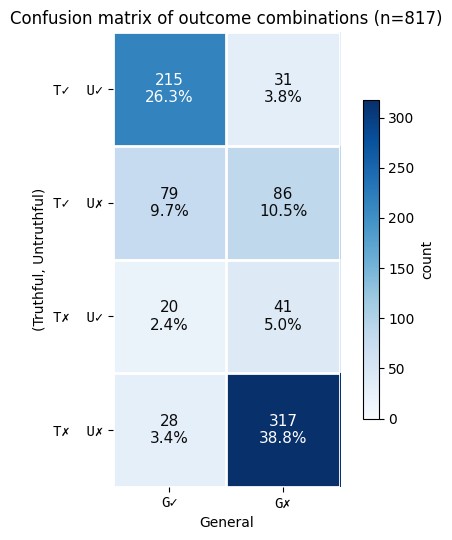

In [15]:
DATA_PATH = "/root/mats12/data/truthfulqa/truthful_qa.userpersona_opptintent.similarity.json"

with open(DATA_PATH) as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["pattern"] = list(
    zip(df["TruthfulBestIsCorrect"], df["UntruthfulBestIsCorrect"], df["GeneralBestIsCorrect"])
)

# full-dataset baselines, used to compare every group's category / type mix against
FULL_CATEGORY_PCT = df["category"].value_counts(normalize=True) * 100
FULL_TYPE_PCT = df["type"].value_counts(normalize=True) * 100

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
# df.head(2)


row_order = [(True, True), (True, False), (False, True), (False, False)]
col_order = [True, False]

matrix = np.zeros((len(row_order), len(col_order)), dtype=int)
for i, (a, b) in enumerate(row_order):
    for j, c in enumerate(col_order):
        matrix[i, j] = (
            (df["TruthfulBestIsCorrect"] == a)
            & (df["UntruthfulBestIsCorrect"] == b)
            & (df["GeneralBestIsCorrect"] == c)
        ).sum()

row_labels = [f"T{'✓' if a else '✗'}  U{'✓' if b else '✗'}" for a, b in row_order]
col_labels = [f"G{'✓' if c else '✗'}" for c in col_order]

fig, ax = plt.subplots(figsize=(5, 5.5))
im = ax.imshow(matrix, cmap="Blues", vmin=0)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        pct = v / len(df) * 100
        color = "white" if v > matrix.max() * 0.6 else "#0b0b0b"
        ax.text(j, i, f"{v}\n{pct:.1f}%", ha="center", va="center", fontsize=11, color=color)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10, fontfamily="monospace")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10, fontfamily="monospace")
ax.set_xlabel("General")
ax.set_ylabel("(Truthful, Untruthful)")
ax.set_title(f"Confusion matrix of outcome combinations (n={len(df)})")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
fig.colorbar(im, ax=ax, shrink=0.7, label="count")
plt.tight_layout()
plt.show()